## A.I. Assignment 5

## Learning Goals

By the end of this lab, you should be able to:
* Get more familiar with tensors in pytorch 
* Create a simple multilayer perceptron model with pytorch
* Visualise the parameters


### Task

Build a fully connected feed forward network that adds two bits. Determine the a propper achitecture for this network (what database you use for this problem? how many layers? how many neurons on each layer? what is the activation function? what is the loss function? etc)

Create at least 3 such networks and compare their performance (how accurate they are?, how farst they are trained to get at 1 accuracy?)

Display for the best one the weights for each layer.


In [2]:
import torch
import torch.nn as nn
from collections import OrderedDict
torch.manual_seed(0)

In [3]:
model1 = nn.Sequential(OrderedDict([
    ('hidden1', nn.Linear(2, 4)),
    ('activation1',    nn.ReLU()),
    ('output',  nn.Linear(4, 3))
]))

model2 = nn.Sequential(OrderedDict([
    ('hidden2', nn.Linear(2, 4)),
    ('activation2',    nn.Tanh()),
    ('output',  nn.Linear(4, 3))
]))

model3 = nn.Sequential(OrderedDict([
    ('hidden3', nn.Linear(2, 4)),
    ('activation3',    nn.Sigmoid()),
    ('output',  nn.Linear(4, 3))
]))

In [4]:
print(model1)
print(model2)
print(model3)

Sequential(
  (hidden1): Linear(in_features=2, out_features=4, bias=True)
  (activation1): ReLU()
  (output): Linear(in_features=4, out_features=3, bias=True)
)
Sequential(
  (hidden2): Linear(in_features=2, out_features=4, bias=True)
  (activation2): Tanh()
  (output): Linear(in_features=4, out_features=3, bias=True)
)
Sequential(
  (hidden3): Linear(in_features=2, out_features=4, bias=True)
  (activation3): Sigmoid()
  (output): Linear(in_features=4, out_features=3, bias=True)
)


In [5]:
data_in = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])
print(data_in)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


In [6]:
data_target = torch.tensor([0, 1, 1, 2])
print(data_target)

tensor([0, 1, 1, 2])


In [ ]:
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model1.parameters(), lr=0.01)

In [7]:
def train_model(model, epochs=2000):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    first_perfect = None
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(data_in)
        loss = criterion(outputs, data_target)
        loss.backward()
        optimizer.step()
        
        predicted = torch.argmax(outputs, dim=1)
        accuracy = (predicted == data_target).float().mean().item()
        
        if accuracy == 1.0 and first_perfect is None:
            first_perfect = epoch + 1
        
        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}")
    
    print(f"Reached 100% at epoch {first_perfect}")

print("Model 1 - ReLU")
train_model(model1)
print("\nModel 2 - Tanh")
train_model(model2)
print("\nModel 3 - Sigmoid")
train_model(model3)

Model 1 - ReLU
Epoch 500, Loss: 0.0182, Accuracy: 1.00
Epoch 1000, Loss: 0.0049, Accuracy: 1.00
Epoch 1500, Loss: 0.0023, Accuracy: 1.00
Epoch 2000, Loss: 0.0013, Accuracy: 1.00
Reached 100% at epoch 50

Model 2 - Tanh
Epoch 500, Loss: 0.0044, Accuracy: 1.00
Epoch 1000, Loss: 0.0012, Accuracy: 1.00
Epoch 1500, Loss: 0.0005, Accuracy: 1.00
Epoch 2000, Loss: 0.0003, Accuracy: 1.00
Reached 100% at epoch 49

Model 3 - Sigmoid
Epoch 500, Loss: 0.0443, Accuracy: 1.00
Epoch 1000, Loss: 0.0090, Accuracy: 1.00
Epoch 1500, Loss: 0.0037, Accuracy: 1.00
Epoch 2000, Loss: 0.0020, Accuracy: 1.00
Reached 100% at epoch 127


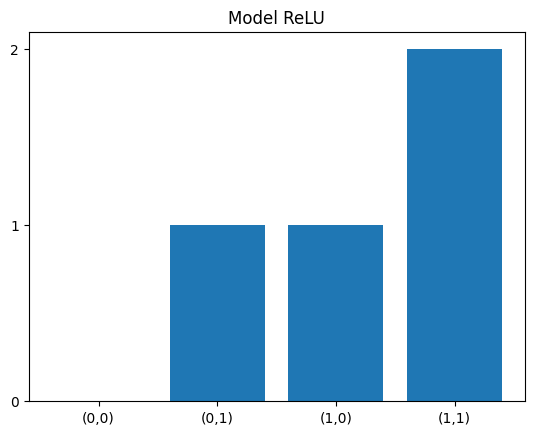

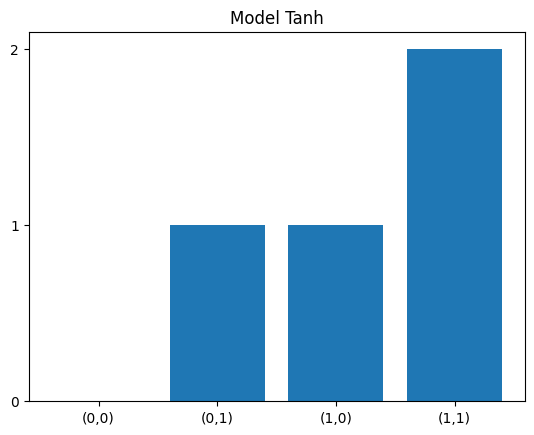

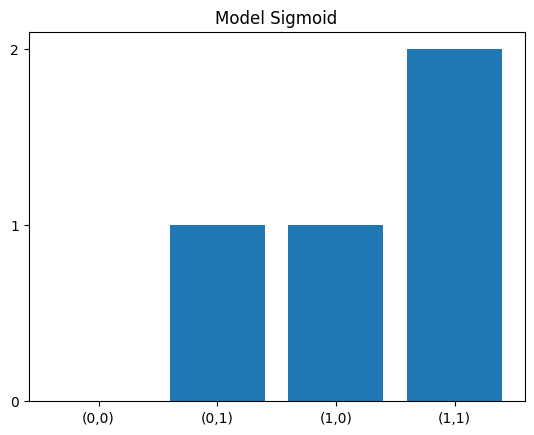

In [8]:
import matplotlib.pyplot as plt

with torch.no_grad():
    for model, name in zip([model1, model2, model3], ['ReLU', 'Tanh', 'Sigmoid']):
        predicted = torch.argmax(model(data_in), dim=1).numpy()
        plt.bar(['(0,0)', '(0,1)', '(1,0)', '(1,1)'], predicted)
        plt.title(f'Model {name}')
        plt.yticks([0, 1, 2])
        plt.show()

In [9]:
print("Model 2 is the best one because it reached 100% accuracy the fastest.")
for param_name, param in model2.named_parameters():
    print(f"{param_name}: {param.data.numpy().round(4)}")

Model 2 is the best one because it reached 100% accuracy the fastest.
hidden2.weight: [[-2.6635 -2.4884]
 [-2.3016 -2.3281]
 [ 1.7238  1.8117]
 [-2.3279 -2.1566]]
hidden2.bias: [ 1.0753  1.0014 -2.3941  3.26  ]
output.weight: [[ 2.3455  2.0843 -2.4698  1.2401]
 [-2.8015 -3.6372 -3.3953  3.459 ]
 [-1.3501 -1.8701  2.8962 -1.781 ]]
output.bias: [ 1.1759 -1.6681 -0.152 ]
